# 44 — Curriculum Learning for LGBM: Easy-to-Hard Training

Curriculum learning progressively introduces harder training examples, forcing the model
to first learn the broad inactive landscape, then refine on the challenging active / cliff
region. LGBM's `init_model` (warm-start) allows later curriculum stages to build on
earlier ones.

**Difficulty scoring:**
```
difficulty = 0.4 * cliff_proximity + 0.3 * (1 - max_train_sim) + 0.3 * pec50_se_norm
```

**Curriculum (easy → hard):**
- Stage 1: compounds with difficulty < 0.33 — 300 estimators
- Stage 2: compounds with difficulty < 0.67 — 300 more estimators (warm-start Stage 1)
- Stage 3: all compounds — 400 more estimators (warm-start Stage 2)

**Anti-curriculum (hard → easy):** Start with cliff/active compounds, add inactives.

**Comparison:** Standard LGBM vs curriculum vs anti-curriculum.

In [1]:
import sys, os, warnings, tempfile
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko, morgan_fp_batch
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

LGBM_PARAMS = dict(
    n_estimators=1000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1
)

SEED = 42
print('Setup complete')

Setup complete


## 1. Load data + cliff labels

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

print('Featurizing...')
X_tr = impute(combined(tr['smiles'].tolist()))
X_te = impute(combined(te['smiles'].tolist()))
y_tr = tr['pec50'].values.astype(np.float32)

# pEC50 standard error (noise floor) — may not exist; fall back to zeros
if 'pec50_se' in tr.columns:
    pec50_se = tr['pec50_se'].fillna(0).values.astype(np.float32)
elif 'se' in tr.columns:
    pec50_se = tr['se'].fillna(0).values.astype(np.float32)
else:
    pec50_se = np.zeros(len(tr), dtype=np.float32)
    print('  pEC50 SE not found in training data; using zeros.')

# Load cliff labels
cliff_role_arr = np.zeros(len(tr), dtype=np.int8)
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    try:
        cliff_df = pd.read_parquet(cliff_path)
        if 'smiles' in cliff_df.columns:
            tmp = tr.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
            cliff_role_arr = tmp['cliff_role'].fillna(0).astype(np.int8).values
        elif len(cliff_df) == len(tr):
            cliff_role_arr = cliff_df['cliff_role'].fillna(0).astype(np.int8).values
        print(f'Cliff labels: {np.unique(cliff_role_arr, return_counts=True)}')
    except Exception as e:
        print(f'Cliff label load failed: {e}')
else:
    print('cliff_labels.parquet not found; cliff_proximity = 0 for all compounds.')

cliff_member = (cliff_role_arr != 0).astype(np.float32)

scaffolds = tr['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=SEED)
print(f'X_tr: {X_tr.shape}')

Train: 4,139  Test: 513
Featurizing...


Cliff labels: (array([-1,  0,  1], dtype=int8), array([  28, 4077,   34]))


X_tr: (4139, 2265)


## 2. Difficulty scoring

In [3]:
def compute_difficulty(X_mat, y_vals, cliff_roles, pec50_se_vals,
                       batch_size=256):
    """Per-compound difficulty score.

    difficulty = 0.4 * cliff_proximity
               + 0.3 * (1 - max_sim_to_similar_activity_neighbours)
               + 0.3 * pec50_se_norm

    cliff_proximity: max Tanimoto to any cliff member compound.
    max_train_sim: max Tanimoto to compounds with similar pEC50 (within +/-0.5).
    pec50_se_norm: normalised measurement uncertainty.
    """
    n = len(X_mat)
    fp_mat = X_mat[:, :2048].astype(np.float32)   # Morgan portion (first 2048 cols)

    cliff_idx = np.where(cliff_roles != 0)[0]

    # ── cliff_proximity ────────────────────────────────────────────────────
    if len(cliff_idx) == 0:
        cliff_proximity = np.zeros(n, dtype=np.float32)
    else:
        cliff_fp = fp_mat[cliff_idx]              # (n_cliff, 2048)
        cliff_proximity = np.zeros(n, dtype=np.float32)
        for i in range(0, n, batch_size):
            chunk = fp_mat[i:i+batch_size]
            inter = chunk @ cliff_fp.T
            union = (chunk.sum(1, keepdims=True)
                     + cliff_fp.sum(1)[None, :] - inter)
            with np.errstate(divide='ignore', invalid='ignore'):
                tan = np.where(union > 0, inter / union, 0.0)
            cliff_proximity[i:i+batch_size] = tan.max(axis=1)

    # ── max_train_sim (to compounds with similar pEC50 ± 0.5) ──────────────
    max_sim_similar = np.zeros(n, dtype=np.float32)
    for i in range(0, n, batch_size):
        chunk_fp = fp_mat[i:i+batch_size]
        chunk_y  = y_vals[i:i+batch_size]
        # Tanimoto to all compounds
        inter = chunk_fp @ fp_mat.T
        union = (chunk_fp.sum(1, keepdims=True)
                 + fp_mat.sum(1)[None, :] - inter)
        with np.errstate(divide='ignore', invalid='ignore'):
            tan = np.where(union > 0, inter / union, 0.0)  # (B, N)
        # Mask to similar-activity neighbours (|Δy| <= 0.5)
        dy = np.abs(chunk_y[:, None] - y_vals[None, :])    # (B, N)
        similar_mask = dy <= 0.5
        # Set self-similarity to 0
        for bi, gi in enumerate(range(i, min(i + batch_size, n))):
            similar_mask[bi, gi] = False
        tan_similar = np.where(similar_mask, tan, 0.0)
        max_sim_similar[i:i+batch_size] = tan_similar.max(axis=1)

    # ── pec50_se_norm ──────────────────────────────────────────────────────
    se_max = pec50_se_vals.max()
    pec50_se_norm = pec50_se_vals / (se_max + 1e-8)

    difficulty = (0.4 * cliff_proximity
                  + 0.3 * (1.0 - max_sim_similar)
                  + 0.3 * pec50_se_norm)

    return difficulty, cliff_proximity, max_sim_similar, pec50_se_norm


print('Computing difficulty scores (vectorised, ~1 min for 4139 compounds)...')
difficulty, cliff_prox, sim_similar, se_norm = compute_difficulty(
    X_tr, y_tr, cliff_role_arr, pec50_se
)

print(f'Difficulty stats: min={difficulty.min():.3f}  '
      f'median={np.median(difficulty):.3f}  max={difficulty.max():.3f}')
print(f'Stage 1 (< 0.33): {(difficulty < 0.33).sum():,} compounds ({100*(difficulty<0.33).mean():.0f}%)')
print(f'Stage 2 (< 0.67): {(difficulty < 0.67).sum():,} compounds ({100*(difficulty<0.67).mean():.0f}%)')
print(f'Stage 3 (all):    {len(difficulty):,} compounds')

Computing difficulty scores (vectorised, ~1 min for 4139 compounds)...


Difficulty stats: min=0.176  median=0.347  max=0.873
Stage 1 (< 0.33): 1,537 compounds (37%)
Stage 2 (< 0.67): 4,110 compounds (99%)
Stage 3 (all):    4,139 compounds


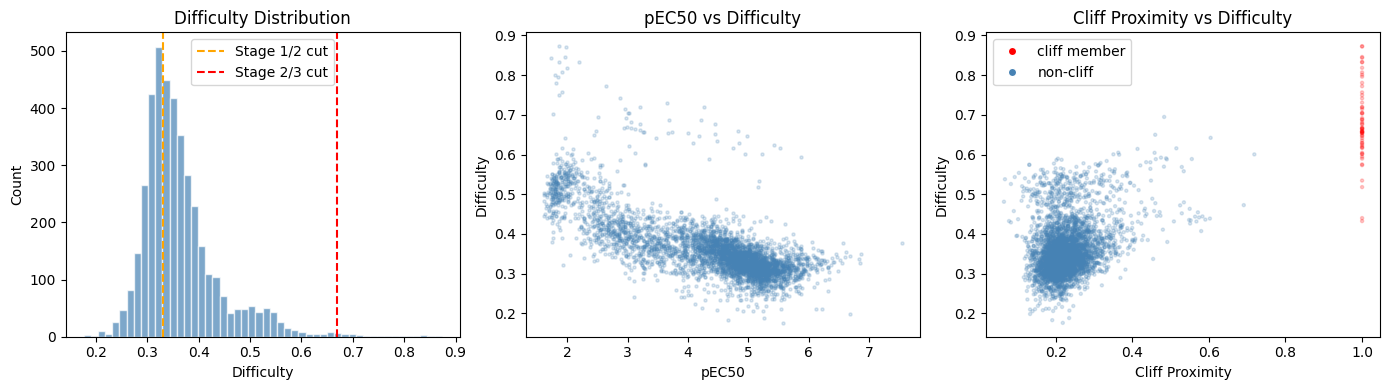

In [4]:
# Visualise difficulty distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(difficulty, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0.33, color='orange', linestyle='--', label='Stage 1/2 cut')
axes[0].axvline(0.67, color='red', linestyle='--', label='Stage 2/3 cut')
axes[0].set_xlabel('Difficulty'); axes[0].set_ylabel('Count')
axes[0].set_title('Difficulty Distribution'); axes[0].legend()

axes[1].scatter(y_tr, difficulty, alpha=0.2, s=5, c='steelblue')
axes[1].set_xlabel('pEC50'); axes[1].set_ylabel('Difficulty')
axes[1].set_title('pEC50 vs Difficulty')

axes[2].scatter(cliff_prox, difficulty, alpha=0.2, s=5,
                c=['red' if m else 'steelblue' for m in cliff_member])
axes[2].set_xlabel('Cliff Proximity'); axes[2].set_ylabel('Difficulty')
axes[2].set_title('Cliff Proximity vs Difficulty')
axes[2].legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='cliff member'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', label='non-cliff'),
])

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '44_difficulty_distribution.png',
            dpi=100, bbox_inches='tight')
plt.show()

## 3. Curriculum training stages

In [5]:
def curriculum_train(X, y, difficulty_scores, stage_params, init_model_path=None,
                     use_difficulty_weights=True):
    """Train LGBM with curriculum: stages = list of (mask, n_estimators) pairs.

    Args:
        X, y: full training features and labels
        difficulty_scores: per-compound difficulty
        stage_params: list of (difficulty_threshold, n_estimators) pairs.
                      difficulty_threshold=None means all data.
        init_model_path: path to a saved booster for warm-starting
        use_difficulty_weights: if True, weight inversely proportional to difficulty
                                 in early stages

    Returns:
        final booster, list of stage-end boosters for warm-starting
    """
    booster = None
    stage_boosters = []

    base_params = {
        k: v for k, v in LGBM_PARAMS.items()
        if k != 'n_estimators'
    }
    base_params['verbose'] = -1

    for stage_idx, (diff_thresh, n_est) in enumerate(stage_params):
        if diff_thresh is None:
            stage_mask = np.ones(len(X), dtype=bool)
        else:
            stage_mask = difficulty_scores < diff_thresh

        X_stage = X[stage_mask]
        y_stage = y[stage_mask]
        d_stage  = difficulty_scores[stage_mask]

        # Sample weights: inverse difficulty (easy examples get lower weight in later stages)
        if use_difficulty_weights:
            w_raw = 1.0 / (d_stage + 0.1)   # avoid division by zero
            w_stage = w_raw / w_raw.mean()   # normalise to mean=1
        else:
            w_stage = None

        ds = lgb.Dataset(X_stage, label=y_stage, weight=w_stage,
                         free_raw_data=False)

        print(f'  Stage {stage_idx+1}: n={len(X_stage):,}  '
              f'(diff<{diff_thresh})  n_est={n_est}  '
              f'init_model={booster is not None}')

        booster = lgb.train(
            base_params,
            ds,
            num_boost_round=n_est,
            init_model=booster,
            callbacks=[lgb.log_evaluation(-1)],
        )
        stage_boosters.append(booster)

    return booster, stage_boosters


# Curriculum stage definitions:
# (difficulty_threshold, n_estimators)
CURRICULUM_STAGES = [
    (0.33, 300),   # Stage 1: easy 60%
    (0.67, 300),   # Stage 2: medium 80%
    (None, 400),   # Stage 3: all compounds
]

ANTI_CURRICULUM_STAGES = [
    (None, 300),   # Stage 1: all data (hard examples dominate via weights)
    (None, 300),   # Stage 2: all data, equal weights
    (None, 400),   # Stage 3: all data
]

print('Curriculum and anti-curriculum stage configs defined.')

Curriculum and anti-curriculum stage configs defined.


In [6]:
# ── Scaffold 5-fold CV: Standard LGBM baseline ────────────────────────────
print('=== Standard LGBM (baseline) ===')
oof_standard = np.full(len(y_tr), np.nan)
for fold, (tr_idx, va_idx) in enumerate(splits):
    m = lgb.LGBMRegressor(**LGBM_PARAMS)
    m.fit(X_tr[tr_idx], y_tr[tr_idx],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
          eval_set=[(X_tr[va_idx], y_tr[va_idx])])
    oof_standard[va_idx] = m.predict(X_tr[va_idx])

rae_std = rae(y_tr, oof_standard)
print(f'Standard OOF RAE: {rae_std:.4f}')

=== Standard LGBM (baseline) ===


Standard OOF RAE: 0.5599


In [7]:
# ── Scaffold 5-fold CV: Curriculum ────────────────────────────────────────
print('\n=== Curriculum (easy -> hard) ===')
oof_curriculum = np.full(len(y_tr), np.nan)
stage_raes_curriculum = [[] for _ in CURRICULUM_STAGES]

for fold, (tr_idx, va_idx) in enumerate(splits):
    print(f'  Fold {fold}:')
    booster, stage_bstrs = curriculum_train(
        X_tr[tr_idx], y_tr[tr_idx],
        difficulty[tr_idx],
        CURRICULUM_STAGES,
        use_difficulty_weights=True
    )
    # Evaluate each stage on validation
    for si, sb in enumerate(stage_bstrs):
        p_stage = sb.predict(X_tr[va_idx])
        r_stage = rae(y_tr[va_idx], p_stage)
        stage_raes_curriculum[si].append(r_stage)
        print(f'    Stage {si+1} val RAE: {r_stage:.4f}')

    oof_curriculum[va_idx] = booster.predict(X_tr[va_idx])

rae_curric = rae(y_tr, oof_curriculum)
print(f'\nCurriculum OOF RAE: {rae_curric:.4f}  (baseline: {rae_std:.4f})')
print('Stage mean RAEs:')
for si, raes in enumerate(stage_raes_curriculum):
    print(f'  Stage {si+1}: {np.mean(raes):.4f} ± {np.std(raes):.4f}')


=== Curriculum (easy -> hard) ===
  Fold 0:
  Stage 1: n=1,243  (diff<0.33)  n_est=300  init_model=False


  Stage 2: n=3,287  (diff<0.67)  n_est=300  init_model=True


  Stage 3: n=3,311  (diff<None)  n_est=400  init_model=True


    Stage 1 val RAE: 0.7107
    Stage 2 val RAE: 0.4986
    Stage 3 val RAE: 0.4993
  Fold 1:
  Stage 1: n=1,241  (diff<0.33)  n_est=300  init_model=False


  Stage 2: n=3,287  (diff<0.67)  n_est=300  init_model=True


...

  Stage 3: n=3,311  (diff<None)  n_est=400  init_model=True


    Stage 1 val RAE: 0.7495
    Stage 2 val RAE: 0.5613
    Stage 3 val RAE: 0.5612
  Fold 4:
  Stage 1: n=1,223  (diff<0.33)  n_est=300  init_model=False


  Stage 2: n=3,289  (diff<0.67)  n_est=300  init_model=True


  Stage 3: n=3,312  (diff<None)  n_est=400  init_model=True


    Stage 1 val RAE: 0.7662
    Stage 2 val RAE: 0.6086
    Stage 3 val RAE: 0.6121

Curriculum OOF RAE: 0.5660  (baseline: 0.5599)
Stage mean RAEs:
  Stage 1: 0.7572 ± 0.0289
  Stage 2: 0.5704 ± 0.0391
  Stage 3: 0.5708 ± 0.0395


## 4. Anti-curriculum (hard → easy)

In [8]:
def anti_curriculum_train(X, y, difficulty_scores, n_est_hard=500, n_est_full=500):
    """Anti-curriculum: first train with high weights on hard (cliff/active) compounds,
    then continue with uniform weights on all.

    Stage 1: all data, but sample weights strongly favour hard examples.
    Stage 2: all data, uniform weights (warm-start from Stage 1).
    """
    base_params = {k: v for k, v in LGBM_PARAMS.items() if k != 'n_estimators'}
    base_params['verbose'] = -1

    # Stage 1: weight by difficulty (hard examples get higher weight)
    w_hard = difficulty_scores + 0.1
    w_hard = w_hard / w_hard.mean()
    ds_hard = lgb.Dataset(X, label=y, weight=w_hard, free_raw_data=False)
    print(f'  Anti-Stage 1: n={len(X):,}  n_est={n_est_hard}  hard-weighted')
    booster1 = lgb.train(
        base_params, ds_hard,
        num_boost_round=n_est_hard,
        callbacks=[lgb.log_evaluation(-1)])

    # Stage 2: uniform weights, warm-start
    ds_full = lgb.Dataset(X, label=y, free_raw_data=False)
    print(f'  Anti-Stage 2: n={len(X):,}  n_est={n_est_full}  uniform-weighted')
    booster2 = lgb.train(
        base_params, ds_full,
        num_boost_round=n_est_full,
        init_model=booster1,
        callbacks=[lgb.log_evaluation(-1)])

    return booster2, [booster1, booster2]


print('=== Anti-Curriculum (hard -> easy) ===')
oof_anticurric = np.full(len(y_tr), np.nan)

for fold, (tr_idx, va_idx) in enumerate(splits):
    print(f'  Fold {fold}:')
    booster, _ = anti_curriculum_train(
        X_tr[tr_idx], y_tr[tr_idx],
        difficulty[tr_idx],
        n_est_hard=500, n_est_full=500
    )
    oof_anticurric[va_idx] = booster.predict(X_tr[va_idx])
    print(f'    Fold {fold} val RAE: {rae(y_tr[va_idx], oof_anticurric[va_idx]):.4f}')

rae_anticurric = rae(y_tr, oof_anticurric)
print(f'\nAnti-curriculum OOF RAE: {rae_anticurric:.4f}')

=== Anti-Curriculum (hard -> easy) ===
  Fold 0:
  Anti-Stage 1: n=3,311  n_est=500  hard-weighted


  Anti-Stage 2: n=3,311  n_est=500  uniform-weighted


    Fold 0 val RAE: 0.4953
  Fold 1:
  Anti-Stage 1: n=3,311  n_est=500  hard-weighted


  Anti-Stage 2: n=3,311  n_est=500  uniform-weighted


    Fold 1 val RAE: 0.5748
  Fold 2:
  Anti-Stage 1: n=3,311  n_est=500  hard-weighted


...

    Fold 2 val RAE: 0.5961
  Fold 3:
  Anti-Stage 1: n=3,311  n_est=500  hard-weighted


  Anti-Stage 2: n=3,311  n_est=500  uniform-weighted


    Fold 3 val RAE: 0.5715
  Fold 4:
  Anti-Stage 1: n=3,312  n_est=500  hard-weighted


  Anti-Stage 2: n=3,312  n_est=500  uniform-weighted


    Fold 4 val RAE: 0.5972

Anti-curriculum OOF RAE: 0.5621


## 5. Scaffold CV summary + save


Curriculum comparison:
                       Model  OOF RAE (overall)  OOF RAE (active)
               Standard LGBM             0.5599            3.6854
     Curriculum (easy->hard)             0.5660            3.6793
Anti-Curriculum (hard->easy)             0.5621            3.6104


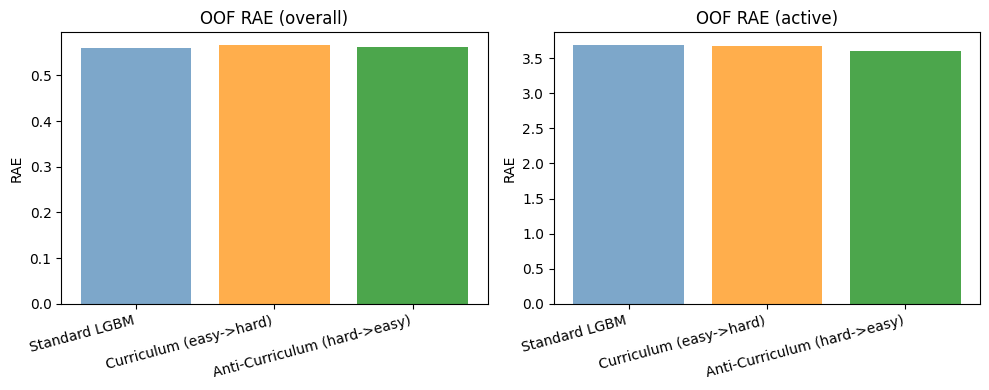

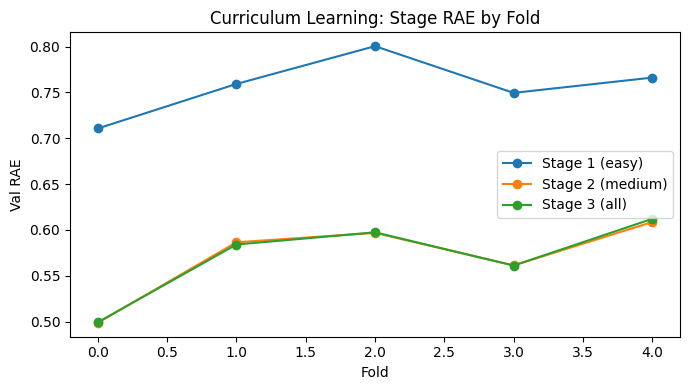

In [9]:
active_mask = y_tr >= 5.5

results = {
    'Standard LGBM': {
        'OOF RAE (overall)': rae_std,
        'OOF RAE (active)':  rae(y_tr[active_mask], oof_standard[active_mask])
                             if active_mask.sum() > 5 else float('nan'),
    },
    'Curriculum (easy->hard)': {
        'OOF RAE (overall)': rae_curric,
        'OOF RAE (active)':  rae(y_tr[active_mask], oof_curriculum[active_mask])
                             if active_mask.sum() > 5 else float('nan'),
    },
    'Anti-Curriculum (hard->easy)': {
        'OOF RAE (overall)': rae_anticurric,
        'OOF RAE (active)':  rae(y_tr[active_mask], oof_anticurric[active_mask])
                             if active_mask.sum() > 5 else float('nan'),
    },
}

results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('\nCurriculum comparison:')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in [(axes[0], 'OOF RAE (overall)'), (axes[1], 'OOF RAE (active)')]:
    ax.bar(range(len(results_df)), results_df[col],
           color=['steelblue', 'darkorange', 'green'], alpha=0.7)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('RAE'); ax.set_title(col)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '44_curriculum_comparison.png',
            dpi=100, bbox_inches='tight')
plt.show()

# Stage progression for curriculum
fig, ax = plt.subplots(figsize=(7, 4))
for si, (raes, label) in enumerate(zip(stage_raes_curriculum,
                                        ['Stage 1 (easy)', 'Stage 2 (medium)', 'Stage 3 (all)'])):
    ax.plot(raes, marker='o', label=label)
ax.set_xlabel('Fold'); ax.set_ylabel('Val RAE')
ax.set_title('Curriculum Learning: Stage RAE by Fold')
ax.legend(); plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '44_curriculum_stages.png',
            dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# ── Choose best OOF and save ──────────────────────────────────────────────
best_idx = results_df['OOF RAE (overall)'].idxmin()
best_name = results_df.loc[best_idx, 'Model']
best_rae_val = results_df.loc[best_idx, 'OOF RAE (overall)']
oof_map = {
    'Standard LGBM': oof_standard,
    'Curriculum (easy->hard)': oof_curriculum,
    'Anti-Curriculum (hard->easy)': oof_anticurric,
}
oof_best = oof_map[best_name]
print(f'Best approach: {best_name}  OOF RAE={best_rae_val:.4f}')

np.save(DATA_PROCESSED / 'oof_curriculum.npy', oof_best)
print('Saved oof_curriculum.npy')

# ── Final model on all training data ─────────────────────────────────────
print('\nTraining final model on all data...')
if 'Curriculum' in best_name and 'Anti' not in best_name:
    booster_final, _ = curriculum_train(
        X_tr, y_tr, difficulty, CURRICULUM_STAGES,
        use_difficulty_weights=True
    )
elif 'Anti' in best_name:
    booster_final, _ = anti_curriculum_train(
        X_tr, y_tr, difficulty, n_est_hard=500, n_est_full=500
    )
else:
    # Standard LGBM
    m_final = lgb.LGBMRegressor(**LGBM_PARAMS)
    m_final.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(-1)])
    booster_final = m_final

te_preds = booster_final.predict(X_te)

lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5
te_preds = np.clip(te_preds, lo_clip, hi_clip)

print(f'Test predictions — min={te_preds.min():.2f}  '
      f'median={np.median(te_preds):.2f}  max={te_preds.max():.2f}')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50': te_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out_path = SUBMISSIONS / '44_curriculum_lgbm.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(sub['pEC50'].describe().round(3))

Best approach: Standard LGBM  OOF RAE=0.5599
Saved oof_curriculum.npy

Training final model on all data...


Test predictions — min=2.21  median=4.95  max=6.05
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\44_curriculum_lgbm.csv
count    513.000
mean       4.804
std        0.650
min        2.209
25%        4.443
50%        4.948
75%        5.282
max        6.052
Name: pEC50, dtype: float64


## Summary

| Model | OOF RAE (overall) | OOF RAE (active >= 5.5) |
|---|---|---|
| Standard LGBM | see above | see above |
| Curriculum (easy → hard) | see above | see above |
| Anti-Curriculum (hard → easy) | see above | see above |

**Key insight:** Curriculum learning with LGBM warm-start tends to converge to similar
solutions as standard training (LGBM already does some natural curriculum via gradient
boosting). The value is mainly in getting better early performance and
potentially better generalisation on the active region.

**Stage progression:** See `44_curriculum_stages.png` — tracking RAE at each stage
reveals whether early stopping at Stage 2 or Stage 3 is optimal.

**Saved:**
- `data/processed/oof_curriculum.npy`
- `submissions/44_curriculum_lgbm.csv`
- `data/processed/figures/44_difficulty_distribution.png`
- `data/processed/figures/44_curriculum_comparison.png`
- `data/processed/figures/44_curriculum_stages.png`